# 05 · Draws from a saved forecast — one unit, one horizon

Read the model output, draw 2,000 samples, done.

`t2-F1-hawkish-cut-2024` · UST_2Y · horizon 126 business days.

In [21]:
import pathlib
import numpy as np, pandas as pd
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)

DATA = (pathlib.Path.cwd() if pathlib.Path.cwd().name == "f1_pipeline" else pathlib.Path.cwd() / "f1_pipeline") / "data"

PRED  = pd.read_parquet(DATA / "f1_predictions.parquet")
POOLS = pd.read_parquet(DATA / "f1_residual_pools.parquet")

UNIT, ASSET, HORIZON = "t2-F1-hawkish-cut-2024", "UST_2Y", 126
print(f"PRED  {PRED.shape}    POOLS {POOLS.shape}")

PRED  (41, 18)    POOLS (129879, 5)


## 1 — The prediction: one row, three numbers

In [22]:
cell_df = PRED[(PRED.unit == UNIT) & (PRED.asset == ASSET) & (PRED.horizon_bd == HORIZON)].reset_index(drop=True)
cell_df[["unit", "asset", "horizon_bd", "asof", "anchor", "mu", "sigma", "value_unit", "n_train"]]

,unit,asset,horizon_bd,asof,anchor,mu,sigma,value_unit,n_train
0,t2-F1-hawkish-cut-2024,UST_2Y,126,2024-12-18,4.35,-0.074199,0.717381,percent_per_annum,5867


In [23]:
ANCHOR = float(cell_df.loc[0, "anchor"])
MU     = float(cell_df.loc[0, "mu"])
SIGMA  = float(cell_df.loc[0, "sigma"])

pd.DataFrame([{"name": "anchor", "value": ANCHOR, "meaning": "the 2Y on the as-of date"},
              {"name": "mu",     "value": MU,     "meaning": "expected change over 126 business days"},
              {"name": "sigma",  "value": SIGMA,  "meaning": "typical size of the error on that expectation"}])

,name,value,meaning
0,anchor,4.350000,the 2Y on the as-of date
1,mu,-0.074199,expected change over 126 business days
2,sigma,0.717381,typical size of the error on that expectation


## 2 — The residual pool: one row per past date

In [24]:
pool_df = (POOLS[(POOLS.unit == UNIT) & (POOLS.asset == ASSET) & (POOLS.horizon_bd == HORIZON)]
           .reset_index(drop=True)[["origin_date", "eps"]])
print(f"{len(pool_df):,} rows · {pool_df.origin_date.min().date()} → {pool_df.origin_date.max().date()}")
pool_df.head()

5,867 rows · 2001-01-03 → 2024-06-17


,origin_date,eps
0,2001-01-03,-0.503901
1,2001-01-04,-0.385640
2,2001-01-05,-0.094706
3,2001-01-08,-0.163313
4,2001-01-09,-0.316900


In [25]:
pool_df.describe().T

,count,mean,min,25%,50%,75%,max,std
origin_date,5867,2012-09-25 13:56:42.420317,2001-01-03 00:00:00,2006-11-15 12:00:00,2012-09-21 00:00:00,2018-08-04 12:00:00,2024-06-17 00:00:00,NaN
eps,5867.0,0.020313,-3.810967,-0.417626,0.044731,0.544964,4.12752,0.999879


## 3 — The draw function

In [27]:
def draws_function(anchor: float, mu: float, sigma: float, pool_df: pd.DataFrame,
                   n_draws: int = 2000, seed: int = 2024) -> pd.DataFrame:
    """value = anchor + mu + sigma * eps, with eps resampled from pool_df [origin_date, eps]."""
    rng  = np.random.default_rng(seed)
    idx  = rng.integers(0, len(pool_df), n_draws)
    out  = pool_df.iloc[idx].reset_index(drop=True).rename(columns={"origin_date": "date_resampled"})
    out.insert(0, "draw", np.arange(n_draws, dtype=np.int32))
    out["value"] = anchor + mu + sigma * out["eps"]
    return out

## 4 — 2,000 draws

In [29]:
forecast_df = draws_function(ANCHOR, MU, SIGMA, pool_df, n_draws=2000, seed=2024)
forecast_df

,draw,date_resampled,eps,value
0,0,2006-09-06,-0.154825,4.164733
1,1,2016-11-08,0.670123,4.756534
2,2,2003-03-07,0.687595,4.769069
3,3,2006-01-18,1.210857,5.144447
4,4,2008-06-17,-2.288193,2.634294
...,...,...,...,...
1995,1995,2022-08-17,1.476022,5.334671
1996,1996,2010-08-20,0.538634,4.662207
1997,1997,2005-06-15,0.899339,4.920970
1998,1998,2011-07-27,-0.392400,3.994300


In [30]:
forecast_df[["eps", "value"]].describe().T

,count,mean,std,min,25%,50%,75%,max
eps,2000.0,0.031436,1.013304,-3.810967,-0.430402,0.040037,0.576425,4.019019
value,2000.0,4.298353,0.726925,1.541885,3.967039,4.304522,4.689317,7.158969


In [31]:
qs = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
quantiles_df = (forecast_df.value.quantile(qs).rename_axis("quantile").reset_index(name="value"))
quantiles_df["quantile"] = (quantiles_df["quantile"] * 100).map(lambda q: f"q{q:02.0f}")
quantiles_df.set_index("quantile").T

quantile,q01,q05,q25,q50,q75,q95,q99
value,2.314062,3.021384,3.967039,4.304522,4.689317,5.398078,6.56276


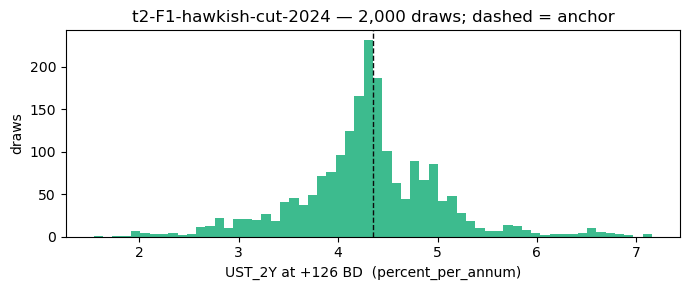

In [32]:
ax = forecast_df.value.plot.hist(bins=60, figsize=(7, 3), color="#1baf7a", alpha=.85)
ax.axvline(ANCHOR, color="#0b0b0b", ls="--", lw=1)
ax.set_xlabel(f"{ASSET} at +{HORIZON} BD  ({cell_df.loc[0, 'value_unit']})"); ax.set_ylabel("draws")
ax.set_title(f"{UNIT} — 2,000 draws; dashed = anchor"); ax.figure.tight_layout()

## 5 — Submission shape

In [33]:
submission_df = pd.DataFrame({"draw": forecast_df.draw, "asset": ASSET,
                              "horizon": np.int32(HORIZON), "value": forecast_df.value})
print(submission_df.dtypes.to_frame("dtype").T.to_string())
submission_df

        draw   asset horizon    value
dtype  int32  object   int32  float64


,draw,asset,horizon,value
0,0,UST_2Y,126,4.164733
1,1,UST_2Y,126,4.756534
2,2,UST_2Y,126,4.769069
3,3,UST_2Y,126,5.144447
4,4,UST_2Y,126,2.634294
...,...,...,...,...
1995,1995,UST_2Y,126,5.334671
1996,1996,UST_2Y,126,4.662207
1997,1997,UST_2Y,126,4.920970
1998,1998,UST_2Y,126,3.994300
